# 1000 Genomes Project

Data preparation

In [1]:
# Automatically reload code in notebook
%load_ext autoreload
%autoreload 2

import pandas as pd
pd.set_option("display.max_columns", None)
import os
os.chdir("/grid/koo/home/schilder/projects/GenomeEncoder/data")

## Custom Python solution

In [41]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("code")
from src.pyensembl import * 
from src.utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
knownCanonical = get_canonical_transcripts()
print(knownCanonical.TranscriptId.nunique(), len(knownCanonical))

86402 86402


In [56]:
import os
os.chdir("/grid/koo/home/schilder/projects/GenomeEncoder/data")

# Load the Reference Genome
vcf_files = list_vcf()

results_all = personalize_proteins(vcf_files, 
                                    ref_genome = "GRCh38/GRCh38_full_analysis_set_plus_decoy_hla.fa",
                                    save_dir = "1KG/sequence_dict_all2",
                                    max_files = 1,
                                    max_samples = None,
                                    max_transcripts = 10,
                                    transcript_ids = knownCanonical['TranscriptId'].tolist(),
                                    max_workers = 1,
                                    # codon_buffer = 'N',
                                    to_stop = False,
                                    force = True)

 

23 VCF files found.


Processing VCF files:   0%|          | 0/1 [00:00<?, ?it/s]

Processing chr14 transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

/grid/koo/home/schilder/.local/lib/python3.9/site-packages/Bio/Seq.py:2879: BiopythonWarning:

Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.



Converting all results to dict.


In [67]:
aa_seqs = get_aa_seqs(results_all)
seq_similarity_df = get_sequence_similarity(results_all, aa_seqs=aa_seqs)
seq_similarity_df.similarity.describe()
seq_similarity_df['similarity_mean'] = seq_similarity_df.groupby('transcript_id')['similarity'].transform('mean')

# plot similarity as boxplot, grouped by transcript
import plotly.express as px
fig = px.box(seq_similarity_df.sort_values(by="similarity_mean", ascending=False),
            x="transcript_id", y="similarity", 
            title=f"Proteoform sequence similarity of {seq_similarity_df.transcript_id.nunique()} transcripts<br>across {len(set(seq_similarity_df.index))} samples")
fig.show()




Processing transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

In [12]:
vcf_in = pysam.VariantFile(vcf_files[0])
chrom = 'chr14'
db = get_db()
tx = db.transcript_by_id("ENST00000163416")
ref_genome = pyfaidx.Fasta("GRCh38/GRCh38_full_analysis_set_plus_decoy_hla.fa")
ref_seq = ref_genome[chrom][tx.start:tx.end].seq
ref_seq = ["".join(x) for x in list(ref_seq)]
nuc_seqs, variant_recorder = personalize_tx_seqs_nuc(tx=tx, vcf_in=vcf_in, ref_genome=ref_genome, ref_seq=ref_seq, sample="HG00273")


In [14]:
import pandas as pd
seq1 = nuc_seqs[0]
seq2 = nuc_seqs[1]
seq_df =  pd.DataFrame({"ref_seq":ref_seq, "seq1":seq1, "seq2":seq2})
# find rows where seq1 and seq2 are not identical to ref_seq
print(seq_df[(seq_df.seq1 != seq_df.ref_seq) | (seq_df.seq2 != seq_df.ref_seq)])
print(len(ref_seq))
print(len(seq1))
print(len(seq2))

offset_ranges = get_offset_ranges(tx)
protseq_ref = translate_seq(subset_seq(ref_seq, offset_ranges))
protseq1 = translate_seq(subset_seq(seq1, offset_ranges))
protseq2 = translate_seq(subset_seq(seq2, offset_ranges))


print("Sequence similarity: subset nuc_seq")
print("seq1:",sequence_similarity(subset_seq(ref_seq, offset_ranges), subset_seq(seq1, offset_ranges)))
print("seq2:",sequence_similarity(subset_seq(ref_seq, offset_ranges), subset_seq(seq2, offset_ranges)))
print("Sequence similarity: subset prot_seq")
print("seq1:",sequence_similarity(protseq_ref, protseq1))
print("seq2:",sequence_similarity(protseq_ref, protseq2))



      ref_seq    seq1    seq2
339         C       T       C
520         G       A       G
587         A     ACT       A
670         A       G       A
781         A       A      AT
...       ...     ...     ...
44397       C  CAAAAA  CAAAAA
44647       C      CA      CA
44656       T       C       T
44668       A      AT      AT
45509       G      GT       G

[176 rows x 3 columns]
45642
45642
45642
Sequence similarity: subset nuc_seq
seq1: 0.9995440036479708
seq2: 1.0
Sequence similarity: subset prot_seq
seq1: 0.9986320109439124
seq2: 1.0


In [190]:
# count frequency of each variant length
from collections import Counter
print(Counter([len(x) for x in ref_seq]))
print(Counter([len(x) for x in seq1]))
print(Counter([len(x) for x in seq2]))


Counter({1: 21959})
Counter({1: 21932, 2: 11, 5: 7, 4: 4, 3: 3, 6: 1, 27: 1})
Counter({1: 21932, 2: 11, 5: 7, 4: 4, 3: 3, 6: 1, 27: 1})


In [58]:
# coding_seq = tx.coding_sequence

# reconstruct coding sequence from relative position ranges
offset_ranges = [tx.offset_range(x[0],x[1]) for x in tx.coding_sequence_position_ranges]
print(offset_ranges)

# spliced_offset_ranges = [(tx.spliced_offset(x[0]), tx.spliced_offset(x[1])) for x in tx.coding_sequence_position_ranges]
# print(spliced_offset_ranges)

spliced_seq = "".join([ref_seq[x[0]-1:x[1]] for x in offset_ranges])
print(spliced_seq)

protein_seq = Seq(spliced_seq).translate(to_stop=False)
print(protein_seq)
print(tx.protein_sequence)

# compute continous score of sequence similarity between tx.protein_sequence and protein_seq
score = sum([1 for x,y in zip(tx.protein_sequence, protein_seq) if x == y]) / len(tx.protein_sequence)
print(score)
# find the first index where the sequences are not identical
index = next((i for i, (x, y) in enumerate(zip(tx.protein_sequence, protein_seq)) if x != y), None)
print(index)

# print(coding_seq)
# print(Seq(coding_seq).translate(to_stop=False))


[(36, 185), (2568, 2701), (3392, 3452), (4776, 4871), (7673, 7726), (7920, 8025), (11271, 11479), (11956, 12105), (12993, 13155), (15057, 15118), (19687, 19776)]
[(36, 185), (186, 319), (320, 380), (381, 476), (477, 530), (531, 636), (637, 845), (846, 995), (996, 1158), (1159, 1220), (1221, 1310)]
ATGGCCGGAGCCGAGGGCGCCGCTGGGCGGCAGTCGGAGCTGGAGCCCGTGGTATCGTTGGTCGACGTCCTTGAGGAGGACGAGGAGCTGGAGAATGAGGCGTGCGCTGTCCTGGGCGGCAGCGACTCCGAGAAGTGCTCCTACTCTCAGGGCTCAGTAAAGAGACAAGCACTATATGCCTGTAGTACCTGCACCCCAGAGGGAGAAGAACCAGCAGGAATTTGTTTAGCTTGCAGTTATGAATGTCATGGAAGTCACAAACTATTTGAGCTATACACAAAAAGAAATTTTCGTTGTGATTGTGGAAACAGCAAGTTTAAAAATTTGGAATGCAAATTACTTCCTGACAAAGCAAAGGTAAATTCTGGCAATAAGTACAATGACAACTTTTTTGGATTGTACTGCATTTGCAAGAGACCTTATCCTGATCCTGAAGACGAGATTCCAGATGAGATGATCCAGTGCGTAGTCTGTGAAGACTGGTTCCATGGAAGGCATCTTGGTGCCATTCCCCCTGAGAGTGGGGATTTTCAGGAGATGGTATGCCAGGCCTGCATGAAACGTTGTTCTTTTTTGTGGGCTTATGCTGCACAATTGGCAGTAACCAAAATATCCACTGAGGATGATGGATTGGTGCGGAACATTGATGGAATAGGTGATCAGGAAGTTATCAAACCTGAAAATGGAGAGCATCAAGATAG

## Variant annotation

In [11]:
import myvariant
# https://docs.myvariant.info/en/latest/doc/data.html#available-fields
mv = myvariant.MyVariantInfo()
mv.get_fields()


{'_seqhashed': {'index': True, 'type': 'object'},
 '_seqhashed._flag': {'index': True, 'type': 'boolean'},
 'cadd': {'index': True, 'type': 'object'},
 'cadd.1000g': {'index': True, 'type': 'object'},
 'cadd.1000g.af': {'index': True, 'type': 'float'},
 'cadd.1000g.afr': {'index': False, 'type': 'float'},
 'cadd.1000g.amr': {'index': False, 'type': 'float'},
 'cadd.1000g.asn': {'index': False, 'type': 'float'},
 'cadd.1000g.eur': {'index': False, 'type': 'float'},
 'cadd.alt': {'analyzer': 'string_lowercase', 'index': True, 'type': 'text'},
 'cadd.anc': {'index': False, 'type': 'text'},
 'cadd.annotype': {'analyzer': 'string_lowercase',
  'index': True,
  'type': 'text'},
 'cadd.bstatistic': {'index': False, 'type': 'integer'},
 'cadd.chmm': {'index': True, 'type': 'object'},
 'cadd.chmm.bivflnk': {'index': False, 'type': 'float'},
 'cadd.chmm.enh': {'index': False, 'type': 'float'},
 'cadd.chmm.enhbiv': {'index': False, 'type': 'float'},
 'cadd.chmm.het': {'index': False, 'type': 'flo

In [13]:
# Query variants in APOE gene with classification and review status
for transcript_id in knownCanonical['TranscriptId'].tolist()[:3]:
    variants = mv.query("BDNF", scopes='clinvar.hg38',assembly='hg38')
    print(f"Found {len(variants['hits'])} variants in {transcript_id}")


Found 10 variants in ENST00000373020
Found 10 variants in ENST00000373031
Found 10 variants in ENST00000371588


### Plot variant counts per transcript

In [49]:
# get variant counts from chr_variant_recorder: iterating through chromosomes, then transcripts, then samples, then variants
from itertools import chain
variant_counts = []
for chrom, variant_recorder in chr_variant_recorder.items():
    for transcript_id, variants in variant_recorder.items():
        # Process one transcript at a time to reduce memory usage
        unique_variants = set(chain.from_iterable(variants.values()))
        variant_counts.append(len(unique_variants))
        del unique_variants
variant_counts = sorted(variant_counts, reverse=True)

In [46]:

variant_counts = sorted(variant_counts.items(), key=lambda x: x[1], reverse=True)
variant_counts
# plotly
interactive = False
if interactive is True:
    import plotly.express as px
    fig = px.histogram(variant_counts, x=1)
    fig.show()
else:
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np
    # Get histogram data
    counts, bins, _ = plt.hist([x[1] for x in variant_counts], bins=100)
    plt.clf() # Clear the figure
    # Create color gradient based on height
    colors = plt.cm.viridis(counts/max(counts))
    # Plot with colors
    plt.bar(bins[:-1], counts, width=np.diff(bins), align='edge', color=colors)
    plt.xlabel('Variant Count')
    plt.ylabel('Frequency') 
    plt.show()

AttributeError: 'list' object has no attribute 'items'

### Compare gene metrics


In [16]:
rgc = pd.read_excel("RGC-ME/41586_2024_7556_MOESM4_ESM.xlsx", sheet_name="table_s2")
rgc.head()

,GeneName,GeneId,TranscriptId,mean,sd,shet_lower,shet_upper,shet_constrained,n,N_total,mutation_rate,MAF,CDS_length,pKO,constraint_group,oe_lof,loeuf,loeuf_underpower,annotations
0,HSPB11,ENSG00000081870,ENST00000194214,0.038708,0.010539,0.023436,0.064243,False,15,1.643240e+06,3.410630e-07,0.000009,435,False,-,0.64467,1.347,0.0,lethal
1,RPL22,ENSG00000116251,ENST00000234875,0.132981,0.074968,0.050899,0.326520,True,4,1.642900e+06,2.946130e-07,0.000002,387,False,-,0.32990,1.036,0.0,"cancer,essential_line"
2,OPRD1,ENSG00000116329,ENST00000234961,0.008655,0.001007,0.006886,0.010856,False,76,1.643860e+06,3.951480e-07,0.000046,1119,True,LO,0.56836,1.193,0.0,ClinVar/HGMD
3,C1orf21,ENSG00000116667,ENST00000235307,0.120590,0.059463,0.051087,0.272217,True,5,1.643923e+06,3.419660e-07,0.000003,366,False,-,0.00000,0.414,0.0,NaN
4,RGS2,ENSG00000116741,ENST00000235382,0.003639,0.000245,0.003191,0.004155,False,222,1.643654e+06,4.884420e-07,0.000135,636,False,-,0.81481,1.417,0.0,"AR,ClinVar/HGMD"


In [25]:
variant_recorder[list(variant_recorder.keys())[0]]


{'HG00096': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00097': ['chr22:15528236_0_0', 'chr22:15528346_1_0'],
 'HG00099': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00100': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00101': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00102': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00103': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00104': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00105': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00106': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00107': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00108': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00109': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00110': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00111': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00112': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00113': ['chr22:15528236_0_0', 'chr22:15528346_0_0'],
 'HG00114': ['

In [17]:
variant_counts = pd.DataFrame({k:len(set(v)) for k,v in variant_recorder.items()}, index=['variant_count']).T
variant_counts['TranscriptId'] = variant_counts.index.str.split('.').str[0]
variant_counts.head()
# merge on TranscriptId
variant_rgc = rgc.merge(variant_counts, on='TranscriptId', how='inner')
print(variant_rgc.shape)
variant_rgc.head()

(144, 20)


,GeneName,GeneId,TranscriptId,mean,sd,shet_lower,shet_upper,shet_constrained,n,N_total,mutation_rate,MAF,CDS_length,pKO,constraint_group,oe_lof,loeuf,loeuf_underpower,annotations,variant_count
0,BCL2L2,ENSG00000129473,ENST00000250405,0.011744,0.001896,0.008625,0.016013,False,40,1.643884e+06,2.803850e-07,0.000024,582,False,-,0.17414,0.826,0.0,NaN,16
1,DAD1,ENSG00000129562,ENST00000250498,0.024242,0.004953,0.016365,0.035704,False,25,1.643946e+06,3.601990e-07,0.000015,342,False,-,0.44592,1.369,1.0,"lethal,essential_line",4
2,SLC39A2,ENSG00000165794,ENST00000298681,0.000866,0.000029,0.000810,0.000924,False,868,1.643916e+06,4.548690e-07,0.000528,930,True,LO,0.66316,1.196,0.0,NaN,44
3,OR5AU1,ENSG00000169327,ENST00000304418,0.000101,0.000004,0.000093,0.000109,False,570,1.643951e+06,3.277900e-08,0.000347,936,True,LO,1.29240,1.891,0.0,NaN,59
4,RNASE3,ENSG00000169397,ENST00000304639,0.001827,0.000853,0.000820,0.003939,False,6,1.643952e+06,3.970000e-09,0.000004,483,False,LO,NaN,NaN,NaN,"HS,ClinVar/HGMD",23


In [18]:
# Plot variant count vs RGC-ME  
import plotly.express as px
fig = px.scatter(variant_rgc, x='variant_count', y='n', hover_data=['TranscriptId'])
fig.show() 

### ESM2

In [4]:
# set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11070). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647378361/work/c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [13]:
# Load the ESM2 Model
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()  # Set model to evaluation mode
print()

In [11]:
# for each proteoform, come up with a unique ID based on the position and identity of each amino acid 
# range(len(protein_seq))
# map each amino acid to a number
def create_proteoform_id(transcript_id,
                         protein_seq):
    token_map = {aa:i for i,aa in enumerate(alphabet.all_toks)}
    return f"{transcript_id}_proteoform{sum([token_map[x]*i for i,x in enumerate(protein_seq)])}"

In [14]:
# Prepare Data for ESM2 Model
variant_map = {} # Maps transcript sequence to variant ID
transcript_to_proteoforms = {} # Maps transcript to variant IDs
proteoforms = {} # Maps transcript,sample,phase to variant ID
stop_codons = {}
samples = []
batches = {}
from tqdm.auto import tqdm

for chrom, transcript_seqs in chr_transcript_seqs.items():
    for transcript_id, protein_seqs in tqdm(transcript_seqs.items(), desc=f"Processing {chrom} transcripts"):
        data = []
        variant_counter = 1
        # print(transcript_id)
        for sample, (protein_seq1, protein_seq2) in protein_seqs.items():
            samples.append(sample) 
            # Process both phases
            for phase, protein_seq in [("phase1", protein_seq1), ("phase2", protein_seq2)]:
                if protein_seq not in variant_map.keys() and protein_seq is not pd.NA:
                    if transcript_id not in transcript_to_proteoforms:
                        transcript_to_proteoforms[transcript_id] = []
                    proteoform_id = create_proteoform_id(transcript_id, protein_seq)
                    variant_map[protein_seq] = proteoform_id
                    data.append((proteoform_id, protein_seq))
                    stop_codons[proteoform_id] = protein_seq.count('*')
                    transcript_to_proteoforms[transcript_id].append(proteoform_id)
                    variant_counter += 1
                proteoforms[(transcript_id,sample,phase)] = variant_map[protein_seq]
        batches[transcript_id] = data

Processing chr14 transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

Processing chr20 transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

Processing chr12 transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

Processing chr5 transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

Processing chr2 transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

...

Processing chr3 transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

Processing chr10 transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

Processing chr7 transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

Processing chr6 transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

Processing chrX transcripts:   0%|          | 0/10 [00:00<?, ?it/s]

In [15]:
print(f"{len(set(proteoforms.values()))} unique proteoforms across {len(set(transcript_seqs.keys()))} transcripts in {len(set(samples))} sample(s).")

2178 unique proteoforms across 10 transcripts in 2548 sample(s).


In [17]:
import os
import pickle

force = False
results = {}
max_transcripts = 5
failed_transcripts = []
i = 1
verbose = False
save_dir="1KG/embeddings/esm2_t33_650M_UR50D"
save_paths = {}
os.makedirs(save_dir, exist_ok=True)

from tqdm import tqdm
if max_transcripts!=None:
    batches_sub = {k: v for k, v in list(batches.items())[:max_transcripts]}
else:
    batches_sub = batches

for transcript_id, data in tqdm(batches_sub.items(), desc="Embedding transcript tokens"): 
    save_path = f"{save_dir}/{transcript_id}.pkl"
    save_paths[transcript_id] = save_path
    try:
        if os.path.exists(save_path) and force is not True:
            if verbose:
                print(f"Loading existing file: {save_path}")
            with open(save_path,'rb') as handle:
                results[transcript_id] = pickle.load(handle) 
        else:
            batch_labels, batch_strs, batch_tokens = batch_converter(data)
            # Generate Embeddings
            with torch.no_grad():
                embeddings = model(batch_tokens, repr_layers=[33], return_contacts=False)
                results[transcript_id] = {
                    'embeddings':embeddings,
                    'batch_labels':batch_labels, 
                    'batch_strs':batch_strs,
                    'batch_tokens':batch_tokens
                }
            # Save 
            with open(save_path,'wb') as handle:
                 pickle.dump(results[transcript_id],
                             handle)
            i += 1
    except Exception as e:
#         print(f"Error with: {save_path}")
#         print(e)
        failed_transcripts.append(transcript_id)
        continue

Embedding transcript tokens: 100%|██████████| 5/5 [00:00<00:00, 22.72it/s]


In [18]:
# List all VCF files in the 1KG directory
import glob
import pickle

# esm2_files = glob.glob('1KG/embeddings/esm2_t33_650M_UR50D/*.pkl')
esm2_files = save_paths.values()
print(f"Found {len(esm2_files)} ESM2 files")
from tqdm import tqdm
def get_sequence_representations(results, data):
    batch_labels = results["batch_labels"]
    return [(batch_labels[i], results["embeddings"]["representations"][33][i, 1 : len(seq) + 1].mean(0, keepdim=False)) for i,(_,seq) in enumerate(data)]
seq_reps = []
for f in tqdm(esm2_files, desc="Extracting sequence representations"):
    transcript_id = os.path.basename(f).replace('.pkl','')
    with open(f,'rb') as handle:
        results = pickle.load(handle) 
    seq_reps += get_sequence_representations(results, batches[transcript_id])

Found 5 ESM2 files


Extracting sequence representations: 100%|██████████| 5/5 [00:00<00:00, 22.50it/s]


In [19]:
# restructure sequence_representations to be a 2D array
save_path = f"1KG/embeddings/esm2_t33_650M_UR50D/sequence_representation_matrix.pt"
force = True
if not os.path.exists(save_path) or force is True:
    print("Restructuring sequence representations into 2D array")
    X = torch.stack([x[1] for x in seq_reps])
    # Save X
    torch.save(X, save_path)
else:
    print("Loading existing sequence representations")
    X = torch.load(save_path)
print(X.shape)

Restructuring sequence representations into 2D array
torch.Size([70, 1280])


In [23]:
transcript_variances = {}
transcript_variance_means = {}
transcript_ids = list(set([x[0].split('_')[0] for x in seq_reps]))
# Compute the variance of each transcript embedding acrosss variants
for transcript_id in tqdm(transcript_ids, desc="Computing transcript variances"):
    # print(transcript_id)
    variant_embeddings = [x[1] for x in seq_reps if x[0].split('_')[0] == transcript_id]
    if len(variant_embeddings) == 1:
        # Set variance to 0 when there is only 1 isoform
        transcript_variances[transcript_id] = torch.zeros(1,variant_embeddings[0].shape[0])
        transcript_variance_means[transcript_id] = 0.0
    else:
        transcript_variances[transcript_id] = torch.stack([x for i,x in enumerate(variant_embeddings)]).var(dim=0)
        transcript_variance_means[transcript_id] = transcript_variances[transcript_id].mean()
    # print(f"> Mean variance: { transcript_variance_means[transcript_id]}")

Computing transcript variances: 100%|██████████| 5/5 [00:00<00:00, 755.92it/s]


In [28]:
variant_proteoform_counts = [len(x[0]) for x in seq_reps]
variant_proteoform_counts = pd.Series(variant_proteoform_counts)
variant_proteoform_counts.head()    

0    34
1    34
2    34
3    34
4    34
dtype: int64

### Embed transcript variants

In [21]:
# Get indicies of rows in X that have Nan
nan_indices = torch.isnan(X).any(dim=1)
print(X.shape)
# Remove rows with Nan
X = X[~nan_indices]
print(X.shape)

torch.Size([70, 1280])
torch.Size([70, 1280])


In [21]:
# Reduce dimensionality of sequence_representations with umap
print("Running UMAP")
import umap
reducer = umap.UMAP()
embedding = reducer.fit_transform(X) 

Running UMAP


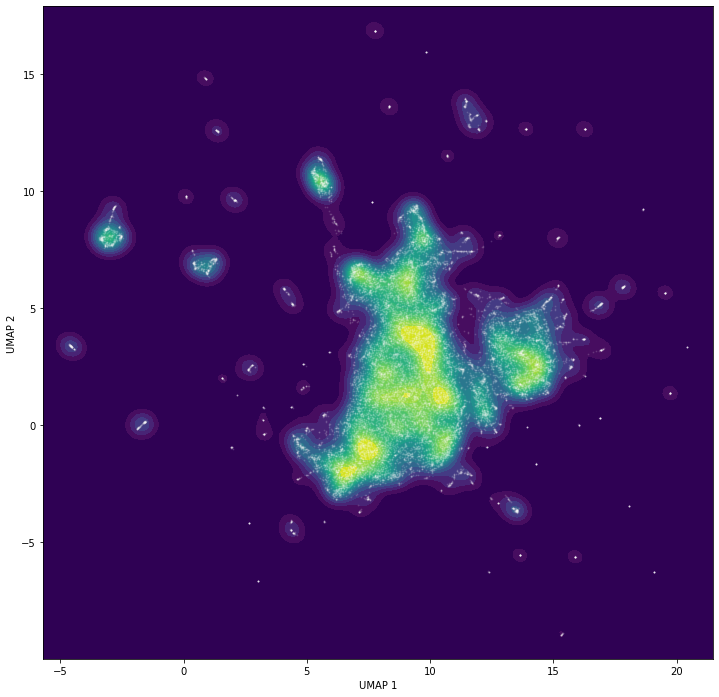

In [36]:
# plot umap with plotly
embedding_df = pd.DataFrame(embedding, columns=['UMAP 1', 'UMAP 2'])
embedding_df['label'] = [x[0] for i,x in enumerate(seq_reps) if not nan_indices[i]]
embedding_df['transcript_id'] = [x.split('_')[0] for x in embedding_df['label']]
embedding_df['transcript'] = [x.split('_')[0].split('.')[0] for x in embedding_df['label']]
interactive = False
if interactive is True:
    import plotly.express as px
    fig = px.scatter(embedding_df, x='UMAP 1', y='UMAP 2', hover_data=['label'], size_max=10, opacity=0.1, 
                    #  color='transcript_id', 
                     height=800, width=900,
                     render_mode='webgl')
    fig.show()
else:
    from matplotlib import pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(12, 12))  # Increase figure size
    # First plot the density contours
    # First plot the density contours with dark background matching lowest density
    plt.gca().set_facecolor('#2F0154') # Set background to slightly darker than darkest viridis color
    sns.kdeplot(data=embedding_df, x='UMAP 1', y='UMAP 2', fill=True, cmap='viridis',
                bw_adjust=0.5, # Decrease bandwidth for higher granularity 
                levels=20, # Increase number of contour levels
                thresh=0.05) # Lower threshold to show more detail
    # Then overlay scatter points with some transparency
    plt.scatter(embedding_df['UMAP 1'], embedding_df['UMAP 2'], 
               alpha=0.1, # Make points semi-transparent
               s=1, # Small point size
               c='white') # White points
    plt.show()

In [ ]:

# Create a density plot of the UMAP embeddings
fig = px.density_contour(embedding_df, x='UMAP 1', y='UMAP 2', nbinsx=200, nbinsy=200,
                          width=800, height=800,
                         marginal_x="histogram", marginal_y="histogram")
# fig.update_traces(contours_coloring="fill", contours_showlabels = True) 
fig.show()


[IUPAC codes](https://www.bioinformatics.org/sms/iupac.html)
| IUPAC nucleotide code | Base |
|----------------------|------|
| A | Adenine |
| C | Cytosine |
| G | Guanine |
| T (or U) | Thymine (or Uracil) |
| R | A or G |
| Y | C or T |
| S | G or C |
| W | A or T |
| K | G or T |
| M | A or C |
| B | C or G or T |
| D | A or G or T |
| H | A or C or T |
| V | A or C or G |
| N | any base |
| . or - | gap |


In [2]:
def download_url(args): 
    import time
    import requests
    import os
    t0 = time.time() 
    url, fn = args[0], args[1] 
    if os.path.exists(fn):
        print("Already exists:",fn)
    else:
        try: 
            r = requests.get(url) 
            with open(fn, 'wb') as f: 
                f.write(r.content) 
                print('url:', url, 'time (s):',time.time())
                return url 
        except Exception as e: 
            print('Exception in download_url():', e)
def download_parallel(args): 
    from os import cpu_count
    from multiprocessing.pool import ThreadPool
    cpus = cpu_count() 
    results = ThreadPool(cpus - 1).imap_unordered(download_url, args)  

def find_file(folder='./',
              name='genomic.gff'):
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file == name:
                return os.path.join(root, file)
    return None
        

## Import metadata

In [3]:
pops = pd.read_csv("https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/phase3/20131219.populations.tsv", sep="\t")
pops.head()

,Population Description,Population Code,Super Population,DNA from Blood,Offspring available from trios,Pilot Samples,Phase1 Samples,Final Phase Samples,Total
0,"Chinese Dai in Xishuangbanna, China",CDX,EAS,no,yes,0.0,0.0,99.0,99.0
1,"Han Chinese in Bejing, China",CHB,EAS,no,no,91.0,97.0,103.0,106.0
2,"Japanese in Tokyo, Japan",JPT,EAS,no,no,94.0,89.0,104.0,105.0
3,"Kinh in Ho Chi Minh City, Vietnam",KHV,EAS,yes,yes,0.0,0.0,101.0,101.0
4,"Southern Han Chinese, China",CHS,EAS,no,yes,0.0,100.0,108.0,112.0


In [19]:
ped = pd.read_csv("https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/release/20130502/integrated_call_samples_v3.20200731.ALL.ped",sep="\t")
print(ped.shape)
ped.head()

(3691, 17)


,Family ID,Individual ID,Paternal ID,Maternal ID,Gender,Phenotype,Population,Relationship,Siblings,Second Order,Third Order,Children,Other Comments,phase 3 genotypes,related genotypes,omni genotypes,affy_genotypes
0,HG00096,HG00096,0,0,1,0,GBR,unrel,0,0,0,0,0,1,0,1,1
1,HG00097,HG00097,0,0,2,0,GBR,unrel,0,0,0,0,0,1,0,1,1
2,HG00098,HG00098,0,0,1,0,GBR,unrel,0,0,0,0,0,0,0,1,1
3,HG00099,HG00099,0,0,2,0,GBR,unrel,0,0,0,0,0,1,0,1,1
4,HG00100,HG00100,0,0,2,0,GBR,unrel,0,0,0,0,0,1,0,1,1


## Download reference genome

In [6]:
ref_fasta=[("http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.fa","../data/GRCh38_full_analysis_set_plus_decoy_hla.fa"),
           ("http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.fa.fai","../data/GRCh38_full_analysis_set_plus_decoy_hla.fa.fai"),
           ("http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.dict","../data/GRCh38_full_analysis_set_plus_decoy_hla.dict")]
download_parallel(ref_fasta)

## Prepare VCFs

### Download VCFs

In [ ]:
seqin = pd.read_csv("https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/phase3/20130502.phase3.analysis.sequence.index", nrows=10, sep="\t")
seqin.head()

,FASTQ_FILE,MD5,RUN_ID,STUDY_ID,STUDY_NAME,CENTER_NAME,SUBMISSION_ID,SUBMISSION_DATE,SAMPLE_ID,SAMPLE_NAME,...,RUN_BLOCK_NAME,INSERT_SIZE,LIBRARY_LAYOUT,PAIRED_FASTQ,WITHDRAWN,WITHDRAWN_DATE,COMMENT,READ_COUNT,BASE_COUNT,ANALYSIS_GROUP
0,data/NA20505/sequence_read/ERR005686_2.filt.fa...,958161180bc95293a1cc29b1082dd685,ERR005686,SRP000540,1000 Genomes Toscan population sequencing,SC,ERA000103,2009-08-28 00:00:00,SRS001673,NA20505,...,NaN,175,PAIRED,data/NA20505/sequence_read/ERR005686_1.filt.fa...,0,NaN,NaN,14586711,1108590036,low coverage
1,data/NA20505/sequence_read/ERR005686.filt.fast...,5ea82f67cdcf1f559561d7dcc68b5eff,ERR005686,SRP000540,1000 Genomes Toscan population sequencing,SC,ERA000103,2009-08-28 00:00:00,SRS001673,NA20505,...,NaN,175,PAIRED,NaN,0,NaN,NaN,510866,38825816,low coverage
2,data/NA20505/sequence_read/ERR005686_1.filt.fa...,c9af10c411ebfb74f6044bb03ec25d68,ERR005686,SRP000540,1000 Genomes Toscan population sequencing,SC,ERA000103,2009-08-28 00:00:00,SRS001673,NA20505,...,NaN,175,PAIRED,data/NA20505/sequence_read/ERR005686_2.filt.fa...,0,NaN,NaN,14586711,1108590036,low coverage
3,data/NA20505/sequence_read/ERR005687.filt.fast...,03a001cd0cdf28cab0a3a2076c7c4125,ERR005687,SRP000540,1000 Genomes Toscan population sequencing,SC,ERA000103,2009-08-28 00:00:00,SRS001673,NA20505,...,NaN,175,PAIRED,NaN,0,NaN,NaN,716917,54485692,low coverage
4,data/NA20505/sequence_read/ERR005687_1.filt.fa...,76f672ead780eb2b19038ab35752d550,ERR005687,SRP000540,1000 Genomes Toscan population sequencing,SC,ERA000103,2009-08-28 00:00:00,SRS001673,NA20505,...,NaN,175,PAIRED,data/NA20505/sequence_read/ERR005687_2.filt.fa...,0,NaN,NaN,15362955,1167584580,low coverage


In [ ]:
vcf_ftp = "http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000_genomes_project/release/20190312_biallelic_SNV_and_INDEL/"
manifest = pd.read_csv(vcf_ftp+"20190312_biallelic_SNV_and_INDEL_MANIFEST.txt", sep="\t", header=None)
manifest = manifest.loc[manifest[0].str.contains("ALL.chr")]
manifest['url'] = vcf_ftp+manifest[0].str.replace(r'^\./', '', regex=True)
manifest['local'] = os.path.abspath("../data/1KG/")+manifest[0].str.replace(r'^\.', '', regex=True)
manifest.head()


,0,1,2,url,local
0,./ALL.chr1.shapeit2_integrated_snvindels_v2a_2...,1040182789,77f154e53c2b7c36b04d03bab3af8b74,http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data...,/grid/koo/home/schilder/projects/GenomeEncoder...
1,./ALL.chr1.shapeit2_integrated_snvindels_v2a_2...,214641,fddc39a4f2357ad0211d6aace27210ae,http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data...,/grid/koo/home/schilder/projects/GenomeEncoder...
2,./ALL.chr2.shapeit2_integrated_snvindels_v2a_2...,1121169725,f9d29c4935e591b2b269eed7cd7e35d8,http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data...,/grid/koo/home/schilder/projects/GenomeEncoder...
3,./ALL.chr2.shapeit2_integrated_snvindels_v2a_2...,226657,3e9ce6dd07c127373e7839cdf2216e04,http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data...,/grid/koo/home/schilder/projects/GenomeEncoder...
4,./ALL.chr3.shapeit2_integrated_snvindels_v2a_2...,953352016,6e59d00235de71562b4199e09b7e5934,http://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data...,/grid/koo/home/schilder/projects/GenomeEncoder...


In [ ]:
url_path_pairs = list(zip(manifest['url'], manifest['local']))
download_parallel(url_path_pairs)

### Define chromosomes

In [3]:
# Create map
chr_map = """
1 chr1
2 chr2
3 chr3
4 chr4
5 chr5
6 chr6
7 chr7
8 chr8
9 chr9
10 chr10
11 chr11
12 chr12
13 chr13
14 chr14
15 chr15
16 chr16
17 chr17
18 chr18
19 chr19
20 chr20
21 chr21
22 chr22
X chrX
"""
# 23 chrX
# 24 chrY
# 25 chrXY
# 26 chrM
# write map to file
with open("../data/chr_name_conv.txt", "w") as f:
    f.write(chr_map)
# Import chromosomes
chrs = pd.read_csv("chr_name_conv.txt", sep=" ", header=None)[1].tolist()
chrs.reverse()
chrs = chrs[:1]
chrs

['chrX']

### Reformat VCFs 

In [ ]:
# Reformat VCFs 
for chr in chrs:
    print("Reformatting",chr)
    out_path = f"1KG/vcf_formatted/ALL.[chr].shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz"
    if not os.path.exists(out_path):
        !module load EBModules BCFtools > /dev/null 2>&1 && \
        bcftools annotate \
            --rename-chrs chr_name_conv.txt \
            1KG/vcf/ALL.{chr}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz \
            -Oz \
            -o {out_path} && \
        bcftools index \
            -t {out_path}
    else:
        print("Skipping",chr)

### Normalise VCFs
Must normalise VCFs to ensure they don't get skipped by bcftools in later steps.

In [5]:
# Normalise VCFs in parallel
from concurrent.futures import ProcessPoolExecutor
import multiprocessing

max_workers = 16 
ncores = multiprocessing.cpu_count()
print(f"Parallelizing across {max_workers}/{ncores} CPU cores")

def normalize_vcf(chr):
    out_path = f"1KG/vcf_norm/ALL.{chr}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz"
    if not os.path.exists(out_path) or not os.path.exists(f"{out_path}.tbi"):
        print("Normalising", chr)
        !module load EBModules BCFtools > /dev/null 2>&1 && \
        bcftools norm \
            -f GRCh38/GRCh38_full_analysis_set_plus_decoy_hla.fa \
            1KG/vcf_formatted/ALL.{chr}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz \
            -Oz \
            -o {out_path} && \
        bcftools index \
            -t {out_path}
    else:
        print("Skipping", chr)

# Process chromosomes in parallel
with ProcessPoolExecutor(max_workers=max_workers) as executor:
    executor.map(normalize_vcf, chrs)

Skipping chrX
Skipping chr22
Skipping chr21
Skipping chr20
Skipping chr19
Skipping chr18
Skipping chr17
Skipping chr16
Skipping chr15
Skipping chr14
Skipping chr13
Skipping chr12
Skipping chr11
Skipping chr10
Skipping chr9
Skipping chr8
Skipping chr7
Skipping chr6
Skipping chr5
Skipping chr4
Skipping chr3
Normalising chr2
Lines   total/split/realigned/skipped:	6790551/0/0/0
Skipping chr1


## Create sequences

Reconstruct full FASTA sequences with the VCFs and ref genome.
- [FastaAlternateReferenceMaker](https://gatk.broadinstitute.org/hc/en-us/articles/360037594571-FastaAlternateReferenceMaker)

###  gatk FastaAlternateReferenceMaker
> This tool works only for SNPs and for simple indels (but not for things like complex substitutions).

In [4]:
# Generate FASTA file for each sample and chromosome

def gatk_FastaAlternateReferenceMaker(chrs, 
                                      max_workers=16,
                                      ref_fa='GRCh38/GRCh38_full_analysis_set_plus_decoy_hla.fa',
                                      in_dir='1KG/vcf_formatted',
                                      out_dir='1KG/gatk_FastaAlternateReferenceMaker',
                                      max_samples=None):
    """
    Generate FASTA files for each sample and chromosome using GATK FastaAlternateReferenceMaker
    
    Args:
        chrs: List of chromosomes to process
        max_workers: Number of parallel processes to use
        max_samples: Maximum number of samples to process
        ref_fa: Path to reference FASTA file
        in_dir: Path to input VCF directory
        out_dir: Path to output FASTA directory
    """
    from concurrent.futures import ProcessPoolExecutor
    from functools import partial
    import multiprocessing

    ncores = multiprocessing.cpu_count()
    print(f"Parallelizing across {max_workers}/{ncores} CPU cores")

    def process_sample(sample, chr):
        out_path = f"{out_dir}/{sample}.{chr}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.fasta"
        if not os.path.exists(out_path) or (os.path.exists(out_path)  and os.path.getsize(out_path) == 0) :
            print(f"Processing Sample: {sample}, Chromosome: {chr}")
            !module load EBModules GATK > /dev/null 2>&1 && \
            gatk FastaAlternateReferenceMaker \
                -R {ref_fa} \
                -V {in_dir}/ALL.{chr}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz \
                -O {out_path} \
                --intervals "{chr}" \
                --use-iupac-sample {sample}
        else:
            print(f"Skipping Sample: {sample}, Chromosome: {chr}")
        return out_path
    # Iterate over chromosome (not parallel)
    for chr in chrs:
        !module load EBModules BCFtools > /dev/null 2>&1 && \
            bcftools query -l {in_dir}/ALL.{chr}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz > samples.txt
        with open('samples.txt', 'r') as f:
            samples = f.read().splitlines()
        if max_samples is not None:
            samples = samples[:max_samples]
        # Process samples in parallel 
        with ProcessPoolExecutor(max_workers=max_workers) as executor:
            process_chr = partial(process_sample, chr=chr)
            executor.map(process_chr, samples)

gatk_FastaAlternateReferenceMaker(chrs, max_samples=2)

Parallelizing across 16/192 CPU cores


### bcftools consensus

-H, --haplotype WHICH         
    choose which allele to use from the FORMAT/GT field, note
    the codes are case-insensitive:  
        1: first allele from GT, regardless of phasing  
        2: second allele from GT, regardless of phasing  
        R: REF allele in het genotypes  
        A: ALT allele  
        I: IUPAC code for all genotypes  
        LR,LA: longer allele and REF/ALT if equal length  
        SR,SA: shorter allele and REF/ALT if equal length  
        1pIu,2pIu: first/second allele for phased and IUPAC code for unphased GTs  

In [47]:
def add_range(bed):
    bed['range'] = bed.apply(lambda x: f"{x[0]}:{x[1]}-{x[2]}", axis=1) 
    
def bed2ranges(bed_file, 
               chr=None,
               temp_dir="/tmp", 
               return_df=False):
    # Create bed file
    import pandas as pd
    bed = pd.read_csv(bed_file, sep="\t", header=None)
    if chr is not None:
        bed = bed.loc[bed[0]==chr]
    else:
            chr = 'ALL'
    sub_path = f"{temp_dir}/cds_ranges.{chr}.bed"
    bed.iloc[:,:3].to_csv(sub_path, sep="\t", index=False, header=None)
    # Create range file
    range_path = sub_path.replace(".bed",".txt")
    add_range(bed)
    bed['range'].to_csv(range_path, sep=" ", index=False, header=None)
    if return_df:
        return bed
    else:
        return sub_path, range_path


In [170]:
def bcftools_consensus(chrs, 
                       in_dir='1KG/vcf_norm',
                       out_dir='1KG/bcftools_consensus',
                       ref_fa='GRCh38/GRCh38_full_analysis_set_plus_decoy_hla.fa',
                       bed_file=None, 
                       mask_file=None,
                       max_samples=None, 
                       phased=True,
                       parallel=True,
                       force=False,
                       max_workers=16):
    """
    Generate FASTA files for each sample and chromosome using bcftools consensus.
    
    Args:
        chrs: List of chromosomes to process
        bed_file: Optional BED file to restrict regions
        max_samples: Maximum number of samples to process per chromosome
        phased: Whether to use phased genotypes
        parallel: Whether to process samples in parallel or sequentially
        processes: Number of parallel processes to use
    """
    from concurrent.futures import ProcessPoolExecutor
    from functools import partial
    import multiprocessing
    import pandas as pd
    import os

    if parallel:
        ncores = multiprocessing.cpu_count()
        print(f"Parallelizing across {max_workers}/{ncores} CPU cores")
    phases = ['1pIu','2pIu'] if phased else ['I'] 
    
    def process_sample(sample, chr, bed_file, mask_file, phases, ref_fa): 
        for phase in phases:
            output_file = f"{out_dir}/{sample}.{chr}.{phase}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.fasta"
            if not os.path.exists(output_file) or force:
                in_vcf = f"{in_dir}/ALL.{chr}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz"
                print(f"\nProcessing {chr}: Sample={sample}, Phase={phase}", flush=True)
                if bed_file is not None:
                    # Subset the BED file to the relevant chromosome and convert to ranges
                    bed_path, range_path = bed2ranges(bed_file, chr=chr)
                    # Subset the VCF to the relevant regions and sample
                    tmp_vcf = f"/tmp/{sample}.{chr}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.cds.vcf.gz"
                    !module load EBModules BCFtools SAMtools > /dev/null 2>&1 && \
                        bcftools view -R {bed_path} -s {sample} -Oz -o {tmp_vcf} {in_vcf} && \
                        bcftools index \
                            -t {tmp_vcf} 
                    # Create reference sequence
                    if mask_file is not None:
                        !module load EBModules BCFtools SAMtools> /dev/null 2>&1 && \
                        samtools faidx {ref_fa} -r {range_path} | \
                        bcftools consensus \
                            -o {output_file} \
                            --missing "?" \
                            --mask {mask_file} \
                            -H {phase} \
                            -s {sample} \
                            {tmp_vcf}
                    else:
                         !module load EBModules BCFtools SAMtools> /dev/null 2>&1 && \
                        samtools faidx {ref_fa} -r {range_path} | \
                        bcftools consensus \
                            -o {output_file} \
                            --missing "?" \
                            -H {phase} \
                            -s {sample} \
                            {tmp_vcf}
                else:
                    # Create reference sequence
                    !module load EBModules BCFtools SAMtools> /dev/null 2>&1 && \
                    samtools faidx {ref_fa} {chr} | \
                    bcftools consensus \
                        -o {output_file} \
                        --missing "?" \
                        -H {phase} \
                        -s {sample} \
                        {in_vcf}
            else:
                print(f"Skipping Sample: {sample}, Chromosome: {chr}, Phase: {phase}", flush=True)
    for chr in chrs:
        !module load EBModules BCFtools > /dev/null 2>&1 && \
            bcftools query -l {in_dir}/ALL.{chr}.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz > samples.txt
        with open('samples.txt', 'r') as f:
            samples = f.read().splitlines()
        if max_samples is not None:
            samples = samples[:max_samples]
        
        if parallel:
            # Process samples in parallel
            with ProcessPoolExecutor(max_workers=max_workers) as executor:
                process_chr = partial(process_sample, chr=chr, bed_file=bed_file, mask_file=mask_file, phases=phases, ref_fa=ref_fa)
                executor.map(process_chr, samples)
        else:
            # Process samples sequentially
            for sample in samples:
                process_sample(sample, chr=chr, bed_file=bed_file, mask_file=mask_file, phases=phases, ref_fa=ref_fa)

In [57]:
bcftools_consensus(chrs, max_samples=2, parallel=False, force=True)



Processing chrX: Sample=HG00096, Phase=1pIu
The site chrX:283075 overlaps with another variant, skipping...
The site chrX:338528 overlaps with another variant, skipping...
The site chrX:347170 overlaps with another variant, skipping...
The site chrX:347173 overlaps with another variant, skipping...
The site chrX:451261 overlaps with another variant, skipping...
The site chrX:456462 overlaps with another variant, skipping...
The site chrX:456463 overlaps with another variant, skipping...
The site chrX:457212 overlaps with another variant, skipping...
The site chrX:490663 overlaps with another variant, skipping...
The site chrX:551548 overlaps with another variant, skipping...
The site chrX:574112 overlaps with another variant, skipping...
The site chrX:592721 overlaps with another variant, skipping...
The site chrX:592722 overlaps with another variant, skipping...
The site chrX:599885 overlaps with another variant, skipping...
The site chrX:651411 overlaps with another variant, skippin

### `pyGeno`

[No longer works](https://github.com/tariqdaouda/pyGeno).

In [78]:
# os.makedirs("/grid/koo/home/schilder/.local/lib/python3.9/site-packages/pyGeno/bootstrap_data/genomes", exist_ok=True)
# os.makedirs("/grid/koo/home/schilder/.local/lib/python3.9/site-packages/pyGeno/bootstrap_data/SNPs", exist_ok=True)

# import pyGeno.bootstrap as B
# B.printDatawraps()
# B.importGenome("Human.GRCh37.75_Y-Only.tar.gz")


## Gather FASTA files

In [154]:
# List all FASTA files generated
import glob
import os

fasta_files = [f for f in glob.glob('1KG/bcftools_consensus_exons/*.fasta*') if f.endswith('.fasta')]
print(f"Found {len(fasta_files)} FASTA files:")      

Found 4 FASTA files:


### Assess sequence content

In [20]:
# from collections import Counter
# from tqdm import tqdm
# # Count unique sequences
# all_seqs = []
# # Get the count of each character in each sequence
# all_counts = {}
# all_lengths = []
# for fasta_key, fasta_seqs in tqdm(fastas.items(), desc="Processing FASTA files"):
#     for s in fasta_seqs:
#         all_seqs.append(s.seq)
#         all_counts[fasta_key+"_"+s.id] = Counter(s.seq)
#         all_lengths.append(len(s.seq))
# print(f"\nNumber of unique sequences: {len(set(all_seqs))}")
# # all_counts 

# seq_lengths = pd.DataFrame(all_lengths).reset_index().rename(columns={0:"length"})
# # seq_lengths.length.describe()
# seq_lengths.length.unique()
# # plotly histogram of sequence lengths
# # import plotly.express as px
# # fig = px.histogram(seq_lengths, x="length", title="Sequence Lengths")
# # fig.show()


## Create amino acid sequences 

### Import GFF annotations

#### `gffutils`

In [7]:
# GRCh38/GCF_000001405.40_GRCh38.p14_genomic.gff.gz
# GRCh38/gencode.v47.annotation.gff3.gz
# GCF_000001405.40/ncbi_dataset/data/GCF_000001405.40/genomic.gff

import gffutils
gff_fn = "GRCh38/gencode.v47.annotation.gff3"
dbfn = f"{gff_fn}.db"
force = True
if os.path.exists(dbfn) and not force:
    print("Using existing db.")
    db = gffutils.FeatureDB(dbfn, keep_order=True)
else:
    print("Creating db.")
    db = gffutils.create_db(gff_fn,
                            dbfn=dbfn,
                            force=force,
                            merge_strategy='create_unique')

Creating db.


#### `gffpandas`

In [43]:
def import_exons(gff_fn = "GRCh38/gencode.v47.annotation.gff3",
                 cds_file = "cds_ranges.txt",
                 exons_file = "exons.tsv.gz",
                 report=True,
                 force = False):
    import gffpandas.gffpandas as gffpd 
    
    if not os.path.exists(exons_file) or force>1:
        if 'exons' not in locals():
            gff = gffpd.read_gff3(gff_fn)
        # print(gff.header)
        # print(gff.df.head())
        # gff.df.groupby('type').seq_id.count().sort_values()
        exons = gff.filter_feature_of_type(['exon']).attributes_to_columns()
        exons = exons.loc[exons.gene_type=='protein_coding']
        # Create name column by joining relevant fields with semicolons
        exons['name'] = exons[['gene_id','transcript_id','exon_id']].apply(lambda x: ';'.join(x), axis=1)
        exons['range'] = exons.apply(lambda x: f"{x.seq_id}:{x.start}-{x.end}", axis=1) 
        exons.to_csv(exons_file, sep="\t", index=False)
    else:
        exons = pd.read_csv(exons_file, sep="\t")
    if report:
        for c in ['gene_id','transcript_id','exon_id','ccdsid']:
            print(exons[c].unique().__len__(),"unique",c)
    # Save as BED file
    if not os.path.exists(cds_file) or force:
        exons[['range']].to_csv(cds_file, sep=" ", index=False, header=None)
        exons[['seq_id','start','end']].to_csv(cds_file.replace(".txt",".bed"), sep="\t", index=False, header=None)
    return exons

exons = import_exons()
exons.head()


20092 unique gene_id
171838 unique transcript_id
630624 unique exon_id
35534 unique ccdsid


,seq_id,source,type,start,end,score,strand,phase,attributes,ID,Parent,ccdsid,exon_id,exon_number,gene_id,gene_name,gene_type,havana_gene,havana_transcript,hgnc_id,level,ont,protein_id,tag,transcript_id,transcript_name,transcript_support_level,transcript_type,name,range
0,chr1,HAVANA,exon,65419,65433,.,+,.,ID=exon:ENST00000641515.2:1;Parent=ENST0000064...,exon:ENST00000641515.2:1,ENST00000641515.2,CCDS30547.2,ENSE00003812156.1,1,ENSG00000186092.7,OR4F5,protein_coding,OTTHUMG00000001094.4,OTTHUMT00000003223.4,HGNC:14825,2,NaN,ENSP00000493376.2,"RNA_Seq_supported_partial,basic,Ensembl_canoni...",ENST00000641515.2,OR4F5-201,NaN,protein_coding,ENSG00000186092.7;ENST00000641515.2;ENSE000038...,chr1:65419-65433
1,chr1,HAVANA,exon,65520,65573,.,+,.,ID=exon:ENST00000641515.2:2;Parent=ENST0000064...,exon:ENST00000641515.2:2,ENST00000641515.2,CCDS30547.2,ENSE00003813641.1,2,ENSG00000186092.7,OR4F5,protein_coding,OTTHUMG00000001094.4,OTTHUMT00000003223.4,HGNC:14825,2,NaN,ENSP00000493376.2,"RNA_Seq_supported_partial,basic,Ensembl_canoni...",ENST00000641515.2,OR4F5-201,NaN,protein_coding,ENSG00000186092.7;ENST00000641515.2;ENSE000038...,chr1:65520-65573
2,chr1,HAVANA,exon,69037,71585,.,+,.,ID=exon:ENST00000641515.2:3;Parent=ENST0000064...,exon:ENST00000641515.2:3,ENST00000641515.2,CCDS30547.2,ENSE00003813949.1,3,ENSG00000186092.7,OR4F5,protein_coding,OTTHUMG00000001094.4,OTTHUMT00000003223.4,HGNC:14825,2,NaN,ENSP00000493376.2,"RNA_Seq_supported_partial,basic,Ensembl_canoni...",ENST00000641515.2,OR4F5-201,NaN,protein_coding,ENSG00000186092.7;ENST00000641515.2;ENSE000038...,chr1:69037-71585
3,chr1,HAVANA,exon,450740,451678,.,-,.,ID=exon:ENST00000426406.4:1;Parent=ENST0000042...,exon:ENST00000426406.4:1,ENST00000426406.4,CCDS72675.1,ENSE00003989331.1,1,ENSG00000284733.2,OR4F29,protein_coding,OTTHUMG00000002860.3,OTTHUMT00000007999.3,HGNC:31275,2,NaN,ENSP00000409316.1,"basic,Ensembl_canonical,GENCODE_Primary,MANE_S...",ENST00000426406.4,OR4F29-201,NaN,protein_coding,ENSG00000284733.2;ENST00000426406.4;ENSE000039...,chr1:450740-451678
4,chr1,HAVANA,exon,685716,686654,.,-,.,ID=exon:ENST00000332831.5:1;Parent=ENST0000033...,exon:ENST00000332831.5:1,ENST00000332831.5,CCDS41221.1,ENSE00004001351.2,1,ENSG00000284662.2,OR4F16,protein_coding,OTTHUMG00000002581.3,OTTHUMT00000007334.3,HGNC:15079,2,NaN,ENSP00000329982.2,"basic,Ensembl_canonical,GENCODE_Primary,MANE_S...",ENST00000332831.5,OR4F16-201,NaN,protein_coding,ENSG00000284662.2;ENST00000332831.5;ENSE000040...,chr1:685716-686654


#### Create CDS consensus FASTA files

In [250]:
bcftools_consensus(chrs, 
                   ref_fa="GRCh38/GRCh38_full_analysis_set_plus_decoy_hla.fa",
                   bed_file="ucsc/ucsc_knownGene_CDS.bed", #"cds_ranges.bed",
                #    mask_file="ucsc/ucsc_knownGene_mask.bed",
                   max_samples=2, 
                   out_dir='1KG/bcftools_consensus_exons', 
                   parallel=False, 
                   force=True)



Processing chrX: Sample=HG00096, Phase=1pIu
The site chrX:283075 overlaps with another variant, skipping...
The site chrX:283075 overlaps with another variant, skipping...
The site chrX:283075 overlaps with another variant, skipping...
The site chrX:283075 overlaps with another variant, skipping...
The site chrX:283075 overlaps with another variant, skipping...
The site chrX:283075 overlaps with another variant, skipping...
The site chrX:338528 overlaps with another variant, skipping...
The site chrX:338528 overlaps with another variant, skipping...
The site chrX:347170 overlaps with another variant, skipping...
The site chrX:347173 overlaps with another variant, skipping...
The site chrX:347170 overlaps with another variant, skipping...
The site chrX:347173 overlaps with another variant, skipping...
The site chrX:347170 overlaps with another variant, skipping...
The site chrX:347173 overlaps with another variant, skipping...
The site chrX:338528 overlaps with another variant, skippin

### Create CDS sequences


In [22]:
def process_exons(fasta_files,
                        exons,
                        transcripts=None,
                        max_transcripts=None,
                        extra_cols=['gene_id','gene_name','hgnc_id','protein_id'],
                        return_df=False,
                        save_dir='1KG/cds_transcripts',
                        force=False):
    # https://www.rpgroup.caltech.edu/bige105/2018/code/t01_sequence_analysis_enamel.html
    from Bio import SeqIO
    from Bio.Seq import Seq
    samples = list(set([os.path.basename(f).split(".")[0] for f in fasta_files]))

    def process_txs(exons_chr, 
                            df, 
                            transcripts=None,
                            max_transcripts=None):
        from tqdm import tqdm
        def process_tx(tx):
            exons_chr_sub = exons_chr.loc[exons_chr.transcript_id==tx]
            # Count the number of missing exons
            missing_exons = [x for x in exons_chr_sub.range.tolist() if x not in df.id.tolist()]
            df_sub = df.merge(exons_chr_sub, left_on="id", right_on="range", how="right")
            df_sub.sort_values(by=["transcript_id","exon_number"], inplace=True, ascending=[True,True])
            # print(f"Missing {len(missing_exons)} exons for {tx}")
            if df_sub.shape[0]>0:
                nuc = Seq('').join(df.seq.tolist())
                # aa = "".join(df_sub.aa)
                d  = {'nuc': nuc,
                        # 'aa': aa,
                        'nuc_len': len(nuc),
                        # 'aa_len': len(aa),
                        # 'aa_stop_count': aa.count("*"),
                        'exon_total': max(df_sub.exon_number),
                        # 'exon_count': df_sub.loc[pd.notna(df_sub.aa),:].exon_id.unique().__len__(),
                        'missing_exons': len(missing_exons), 
                        'seq_id':df_sub.seq_id[0],
                        'start':min(df_sub.start),
                        'end':max(df_sub.end)
                        }
                for col in extra_cols:
                    d[col] = df_sub[col].unique()[0] 
                return d
            else:
                print(f"Warning: No sequences found for {tx}")
                return None
        transcripts = exons_chr.transcript_id.unique()
        if max_transcripts is not None:
            transcripts = transcripts[:max_transcripts]
        seq = dict(filter(None, map(lambda tx: (tx, process_tx(tx)), 
                                tqdm(transcripts, 
                                    desc="Processing transcripts"))))
        seq_df = pd.DataFrame(seq).T
        seq_df.index.name = 'transcript_id'
        return seq_df

    save_fn_all = []
    seq_df_all = pd.DataFrame()
    for s in samples:
        print(s)
        # Import each FASTA file (across chromosomes and phases)
        save_fn = f"{save_dir}/{s}.tsv.gz"
        if os.path.exists(save_fn) and not force:
            print(f"Skipping {s} because it already exists")
            save_fn_all.append(save_fn)
            continue
        fasta_files_sub = [f for f in fasta_files if os.path.basename(f).startswith(s)]
        seq_df_sample = pd.DataFrame()
        for f in fasta_files_sub:
            fn = os.path.basename(f)
            chr = fn.split(".")[1]
            phase = fn.split(".")[2]
            exons_chr = exons.loc[exons.seq_id==chr]
            print(fn)
            df = pd.DataFrame([{'id':x.id, 'seq':x.seq} for x in SeqIO.parse(f, "fasta")])
            seq_df = process_txs(exons_chr, df, 
                                 transcripts=transcripts, 
                                 max_transcripts=max_transcripts)  
            seq_df.insert(0, 'sample', s)
            seq_df.insert(1, 'phase', phase)
            seq_df_sample = pd.concat([seq_df_sample, seq_df])
        if save_dir is not None:
            print("Saving ==>", save_fn)
            seq_df_sample.to_csv(save_fn, sep="\t", index=True)
            save_fn_all.append(save_fn)
        seq_df_all = pd.concat([seq_df_all, seq_df_sample])
    if return_df:
        return save_fn_all, seq_df_all
    else:
        return save_fn_all


cds_files, seq_df_all = process_exons(fasta_files, 
                                    exons, 
                                    max_transcripts=10, 
                                    save_dir=None,
                                    force=True, return_df=True)
    


HG00096
HG00096.chrX.2pIu.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.fasta


Processing transcripts: 100%|██████████| 10/10 [00:00<00:00, 12.85it/s]


HG00096.chrX.1pIu.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.fasta


Processing transcripts: 100%|██████████| 10/10 [00:00<00:00, 13.26it/s]


HG00097
HG00097.chrX.2pIu.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.fasta


Processing transcripts: 100%|██████████| 10/10 [00:00<00:00, 13.40it/s]


HG00097.chrX.1pIu.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.fasta


Processing transcripts: 100%|██████████| 10/10 [00:00<00:00, 13.44it/s]


In [127]:
def find_col(df, prefix, rename=False):
    idx = [i for i in range(0,df.shape[1]-1) if str(df.iloc[:,i].values[0]).startswith(prefix)][0]
    if rename:
        df.rename(columns={df.columns[idx]:prefix}, inplace=True)
        return prefix
    else:
        return idx
def name_enst(df, prefix="ENST"):
    find_col(df, prefix, rename=True)


In [149]:
def process_transcripts(fasta_files, 
                        bed_file="ucsc/ucsc_knownGene_CDS.bed"):
    import pandas as pd
    from Bio import SeqIO

    ## Select subset of transcripts
    transcripts = exons.transcript_id.unique()
    # Import the bed file used to subset the fasta files
    bed = pd.read_csv(bed_file, sep="\t", header=None)
    name_enst(bed, "ENST")
    if transcripts is not None:
        bed = bed.loc[bed['ENST'].isin(transcripts)]
    add_range(bed)
    ### Import the sequences
    # ranges = bed.range.tolist()
    seq_df_all = pd.DataFrame()
    for f in fasta_files:
        print(f)
        df = pd.DataFrame([{'id':x.id, 'nuc':x.seq} for x in SeqIO.parse(f, "fasta")]) # if x.id in ranges
        # find the column where values start with "ENST"
        df = df.loc[df.id.isin(bed.range)]
        df = df.merge(bed, left_on="id", right_on="range", how="left")
        seq_df_all = pd.concat([seq_df_all, df])
    return seq_df_all


In [274]:
seq_df_all = process_transcripts(fasta_files[:1])
seq_df_all.head()

,id,nuc,0,1,2,ENST,4,5,6,7,8,9,10,11,range
0,chrX:281193-288787,"(C, C, T, T, T, T, C, C, A, G, C, T, G, G, C, ...",chrX,281193,288787,ENST00000429181.6,0,+,284187,288787,"0,0,0",4,"63,203,148,55,","0,288,2973,7539,",chrX:281193-288787
1,chrX:283162-288829,"(A, G, T, G, G, C, T, C, A, C, G, C, C, T, G, ...",chrX,283162,288829,ENST00000443019.6,0,+,284187,288829,"0,0,0",3,"39,148,97,","0,1004,5570,",chrX:283162-288829
2,chrX:281054-288869,"(G, G, A, A, G, G, G, A, G, G, C, C, G, T, G, ...",chrX,281054,288869,ENST00000445062.6,0,+,284187,288869,"0,0,0",4,"67,203,148,137,","0,427,3112,7678,",chrX:281054-288869
3,chrX:283733-290757,"(T, G, G, G, C, T, G, G, A, C, C, A, G, C, T, ...",chrX,283733,290757,ENST00000448477.6,0,+,284187,290757,"0,0,0",3,"581,137,110,","0,4999,6914,",chrX:283733-290757
4,chrX:276323-291537,"(T, G, T, T, T, T, A, G, G, A, A, G, A, G, T, ...",chrX,276323,291537,ENST00000484611.7,0,+,276323,276323,"0,0,0",5,"71,148,137,145,39,","0,7843,12409,14324,15175,",chrX:276323-291537


In [271]:
# use first line of bed file as header
bed_tsv_file = "ucsc/ucsc_knownGene.tsv"
# import first line of bed file as header
with open(bed_tsv_file, "r") as f:
    header = f.readline().strip("#").strip()
bed_tsv = pd.read_csv(bed_tsv_file, sep="\t", header=0, comment="#", names=header.split("\t"))
print(bed_tsv .head())

bed = pd.read_csv("ucsc/ucsc_knownGene_CDS.bed", sep="\t", header=None, comment="#")
bed.columns = ['chrom','chromStart','chromEnd','name','score','strand','thickStart','thickEnd','itemRgb','blockCount','blockSizes','blockStarts']
bed.head()


                name chrom strand  txStart  txEnd  cdsStart  cdsEnd  \
0  ENST00000832825.1  chr1      +    11124  14405     11124   11124   
1  ENST00000832826.1  chr1      +    11409  14413     11409   11409   
2  ENST00000832827.1  chr1      +    11410  14413     11410   11410   
3  ENST00000832828.1  chr1      +    11425  14409     11425   11425   
4  ENST00000832829.1  chr1      +    11769  14416     11769   11769   

   exonCount                exonStarts                  exonEnds proteinID  \
0          4  11124,12009,12612,13402,  11211,12227,12721,14405,       NaN   
1          4  11409,12009,12594,13482,  11671,12227,12721,14413,       NaN   
2          4  11410,12009,12612,13482,  11671,12227,12721,14413,       NaN   
3          4  11425,12009,12612,13220,  11671,12227,12721,14409,       NaN   
4          4  11769,12009,12612,13482,  11844,12227,12721,14416,       NaN   

      alignID  
0  uc345qlo.1  
1  uc345qlp.1  
2  uc345qlq.1  
3  uc345qlr.1  
4  uc345qls.1  


,chrom,chromStart,chromEnd,name,score,strand,thickStart,thickEnd,itemRgb,blockCount,blockSizes,blockStarts
0,chr1,11120,14413,ENST00000832824.1,0,+,11120,11120,"0,0,0",4,"91,218,109,961,","0,889,1492,2332,"
1,chr1,11124,14405,ENST00000832825.1,0,+,11124,11124,"0,0,0",4,"87,218,109,1003,","0,885,1488,2278,"
2,chr1,11409,14413,ENST00000832826.1,0,+,11409,11409,"0,0,0",4,"262,218,127,931,","0,600,1185,2073,"
3,chr1,11410,14413,ENST00000832827.1,0,+,11410,11410,"0,0,0",4,"261,218,109,931,","0,599,1202,2072,"
4,chr1,11425,14409,ENST00000832828.1,0,+,11425,11425,"0,0,0",4,"246,218,109,1189,","0,584,1187,1795,"


In [298]:
bed_tsv['exonLengths'] = bed_tsv.apply(lambda x: [int(e)-int(s)+1 for s, e in zip(x.exonStarts.strip(",").split(','), x.exonEnds.strip(",").split(','))], axis=1)
bed_tsv['exonTriplets'] = bed_tsv.apply(lambda x: [int(i)%3==0 for i in x.exonLengths], axis=1)



,name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds,proteinID,alignID,exonLengths,exonTriplets
0,ENST00000832825.1,chr1,+,11124,14405,11124,11124,4,"11124,12009,12612,13402,","11211,12227,12721,14405,",NaN,uc345qlo.1,"[88, 219, 110, 1004]","[False, True, False, False]"
1,ENST00000832826.1,chr1,+,11409,14413,11409,11409,4,"11409,12009,12594,13482,","11671,12227,12721,14413,",NaN,uc345qlp.1,"[263, 219, 128, 932]","[False, True, False, False]"
2,ENST00000832827.1,chr1,+,11410,14413,11410,11410,4,"11410,12009,12612,13482,","11671,12227,12721,14413,",NaN,uc345qlq.1,"[262, 219, 110, 932]","[False, True, False, False]"
3,ENST00000832828.1,chr1,+,11425,14409,11425,11425,4,"11425,12009,12612,13220,","11671,12227,12721,14409,",NaN,uc345qlr.1,"[247, 219, 110, 1190]","[False, True, False, False]"
4,ENST00000832829.1,chr1,+,11769,14416,11769,11769,4,"11769,12009,12612,13482,","11844,12227,12721,14416,",NaN,uc345qls.1,"[76, 219, 110, 935]","[False, True, False, False]"


In [301]:
bed_tsv.loc[pd.notna(bed_tsv.proteinID)]

,name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds,proteinID,alignID,exonLengths,exonTriplets
332,ENST00000641515.2,chr1,+,65418,71585,65564,70008,3,"65418,65519,69036,","65433,65573,71585,",A0A2U3U0J3,uc001aal.2,"[16, 55, 2550]","[False, False, True]"
813,ENST00000426406.4,chr1,-,450739,451678,450739,451678,1,"450739,","451678,",Q6IEY1,uc010nxu.4,[940],[False]
870,ENST00000332831.5,chr1,-,685715,686654,685715,686654,1,"685715,","686654,",Q6IEY1,uc010nxv.4,[940],[False]
1200,ENST00000616016.5,chr1,+,923922,944574,924431,944153,14,"923922,925921,930154,931038,935771,939039,9392...","924948,926013,930336,931089,935896,939129,9394...",A0A087WU74,uc031pkk.3,"[1027, 93, 183, 52, 126, 91, 139, 164, 117, 80...","[False, True, True, False, True, False, False,..."
1201,ENST00000618323.5,chr1,+,923922,944574,924431,944153,14,"923922,925921,930154,931038,935771,939039,9392...","924948,926013,930336,931089,935896,939129,9394...",A0A087WX24,uc057axu.2,"[1027, 93, 183, 52, 126, 91, 142, 164, 117, 80...","[False, True, True, False, True, False, False,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411087,ENST00000612315.1,chr1_KI270713v1_random,-,31697,32528,31841,32372,1,"31697,","32528,",A0AVG0,uc061ftg.1,[832],[False]
411088,ENST00000601199.2,chr1_KI270713v1_random,+,35406,35916,35406,35916,1,"35406,","35916,",P0DMU3,uc032mzh.1,[511],[False]
411538,ENST00000613230.1,chr14_GL000194v1_random,-,53589,115018,53646,54021,3,"53589,112791,114985,","55676,112850,115018,",Q8WZ33,uc059ghq.1,"[2088, 60, 34]","[True, True, False]"
411554,ENST00000618003.1,chr14_KI270726v1_random,+,41443,41876,41443,41876,2,"41443,41571,","41489,41876,",P0DP08,uc059gik.1,"[47, 306]","[False, True]"


In [277]:
from Bio.Seq import Seq
def process_seq(seq_df_all, row):
    start_codon = seq_df_all.nuc[row].transcribe().find("AUG")
    # remove introns
    # Get exon starts and sizes from BED format columns 
    exon_starts = [int(x) for x in seq_df_all.iloc[:,13][row].strip(",").split(',')]  # Column 12 has exon starts
    exon_sizes = [int(x) for x in seq_df_all.iloc[:,12][row].strip(",").split(',')]   # Column 11 has exon sizes
    # Omit first exon 
    # exon_starts = exon_starts[1:]
    # exon_sizes = exon_sizes[1:]
    # # Omit last exon 
    # exon_starts = exon_starts[:-1]
    # exon_sizes = exon_sizes[:-1]
    # Build coding sequence by concatenating exons
    coding_seq = Seq('')
    for start, size in zip(exon_starts, exon_sizes):
        exon = seq_df_all.nuc[row].ungap("-").ungap("?")[start:start+size]
        coding_seq += str(exon)
    return coding_seq

from tqdm import tqdm
seq_df_all['nuc_exon'] = [process_seq(seq_df_all, i) for i, row in tqdm(seq_df_all.iterrows(), desc="Processing transcripts")]
seq_df_all['nuc_exon_len'] = seq_df_all.nuc_exon.apply(lambda x: len(x))
seq_df_all['aa'] = seq_df_all.nuc_exon.apply(lambda x: x.translate(to_stop=True))
seq_df_all['aa_len'] = seq_df_all.aa.apply(lambda x: len(x))
seq_df_all['aa_stop_count'] = seq_df_all.aa.apply(lambda x: x.count("*")) 
seq_df_all['aanostop'] = seq_df_all.nuc_exon.apply(lambda x: x.translate(to_stop=False))
seq_df_all['aanostop_len'] = seq_df_all.aanostop.apply(lambda x: len(x))
seq_df_all['aanostop_stop_count'] = seq_df_all.aanostop.apply(lambda x: x.count("*"))



Processing transcripts: 0it [00:00, ?it/s]

AttributeError: 'Seq' object has no attribute 'ungap'

In [276]:
print(seq_df_all.shape)
seq_df_all.loc[seq_df_all.aanostop_stop_count==0].shape

(6449, 23)


(69, 23)

In [228]:
coding_seq.translate().count("*")

1

In [27]:
seq_df_sample = pd.read_csv(cds_files[0], sep="\t", index_col=None)
seq_df_sample
# [seq_df_sample.aa.count("*") for x in seq_df_sample.aa]

,transcript_id,sample,phase,nuc,aa,nuc_len,aa_len,aa_stop_count,exon_total,exon_count,missing_exons,seq_id,start,end,gene_id,gene_name,hgnc_id,protein_id
0,ENST00000399012.6,HG00097,2pIu,GTGTTTTAGGAAGAGTGTCCCGCAGAGACCCGGCGGGAGCTGCCAG...,VF*EECPAETRRELPGALGFQRLEPPGKPGLSVEEKAAGLLQNLVK...,8694,2886,82,8,8,0,chrX,276322,303353,ENSG00000182378.15,PLCXD1,HGNC:23148,ENSP00000381976.1
1,ENST00000484611.7,HG00097,2pIu,GTTTTAGGAAGAGTGTCCCGCAGAGACCCGGCGGGAGCTGCCAGGA...,VLGRVSRRDPAGAARSSGIPAAGVAQGSPLMGGQVSASNSFSRLHC...,2683,885,33,5,5,0,chrX,276324,291537,ENSG00000182378.15,PLCXD1,HGNC:23148,NaN
2,ENST00000430923.7,HG00097,2pIu,GGCGGGAGCTGCCAGGAGCTCTGGGATTCCAGCGGCTGGAAGGTTG...,GGSCQELWDSSGWKVAQGSPLMGGQVSASNSFSRLHCRNANEDWMS...,3377,1116,32,5,5,0,chrX,276353,291629,ENSG00000182378.15,PLCXD1,HGNC:23148,ENSP00000394848.2
3,ENST00000445062.6,HG00097,2pIu,GAAGGGAGGCCGTGCAGGGGGAGGGGAGGCCGTGCAGGGGGAGGGG...,EGRPCRGRGGRAGGGGAVQAEGPPGKPGLSVEEKAAGLLQNLVKPT...,3104,1024,32,4,4,0,chrX,281055,288869,ENSG00000182378.15,PLCXD1,HGNC:23148,ENSP00000412018.1
4,ENST00000429181.6,HG00097,2pIu,CTTTTCCAGCTGGCTGCAGAGAAGGGGCCAGCTCCCTCCTGGGGAC...,LFQLAAEKGPAPSWGPGAAVQPPGKPGLSVEEKAAGLLQNLVKPTR...,2059,681,2,4,4,0,chrX,281194,288787,ENSG00000182378.15,PLCXD1,HGNC:23148,ENSP00000400904.1
5,ENST00000381657.8,HG00097,2pIu,CTTCCGGGCAGCAGGGAAGATCTGAGTTCATGTAGCTGGTGTTGGC...,LPGSREDLSSCSWCWLRVWEEGFWEDVNKNKICSHLGSLASVWKRR...,8319,2763,82,7,7,0,chrX,281381,303356,ENSG00000182378.15,PLCXD1,HGNC:23148,ENSP00000371073.2
6,ENST00000443019.6,HG00097,2pIu,GTGGCTCACGCCTGTAATCCCAGCACCGCGGAGGTTGCGGTTGCCC...,VAHACNPSTAEVAVAQGSPLMGGQVSASNSFSRLHCRNANEDWMSA...,1468,486,3,3,3,0,chrX,283163,288829,ENSG00000182378.15,PLCXD1,HGNC:23148,ENSP00000408558.1
7,ENST00000415337.6,HG00097,2pIu,ACCCCAGTTCCGTAATATGCAAATGTTGCCCAGGGCTCACCTCTGA...,TPVP*YANVAQGSPLMGGQVSASNSFSRLHCRNANEDWMSALCPRL...,3238,1071,33,5,5,0,chrX,283465,291639,ENSG00000182378.15,PLCXD1,HGNC:23148,ENSP00000399510.1
8,ENST00000447472.6,HG00097,2pIu,ATATGCAAATGTAGGGCGCCATGATGTTCCACACGCCTGGGGGTTG...,ICKCRAP*CSTRLGVAQGSPLMGGQVSASNSFSRLHCRNANEDWMS...,3377,1116,33,5,5,0,chrX,283479,291629,ENSG00000182378.15,PLCXD1,HGNC:23148,ENSP00000405307.1
9,ENST00000448477.6,HG00097,2pIu,GGGCTGGACCAGCTAAAGGCTCGTATTTGCATATTAAAGGTTGCCA...,GLDQLKARICILKVAKPGLRARAFTLDKKHFLELQKMLPRTLFPLS...,1786,589,34,3,3,0,chrX,283734,290757,ENSG00000182378.15,PLCXD1,HGNC:23148,ENSP00000414181.1


### Create CDS FASTA files

In [ ]:
cds_files = [f for f in glob.glob('1KG/cds_transcripts/*.tsv.gz')]

In [220]:
cds_files = [f for f in glob.glob('1KG/cds_transcripts/*.tsv.gz')]

for f in cds_files:
    df = pd.read_csv(f, sep="\t", index_col=None)
    sample = os.path.basename(f).split(".")[0]
    df['fasta'] = df.apply(lambda x: f">{x.transcript_id}\n{x.aa}", axis=1)
    os.makedirs(f"1KG/cds_transcripts/{sample}", exist_ok=True)
    for i, row in df.iterrows():
        fasta_fn = f"1KG/cds_transcripts/{sample}/{row.transcript_id}.aa.fasta"
        with open(fasta_fn, "w") as f:
            f.write(row.fasta + "\n")


## ESM2

## AlphaFold